<a href="https://colab.research.google.com/github/prase2000/Repl_coba/blob/master/99_Credit_SHAP_Untitled36.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LInk:

https://chatgpt.com/g/g-69fab6d318988191881562a2c7d6309f-generator-gap-riset-dan-novelty/c/6a3e32b7-77e0-83ec-b82f-2c1f6d8d022a

In [24]:
pip install lightgbm imbalanced-learn shap scikit-learn scipy pandas numpy matplotlib

In [46]:
import pandas as pd
import numpy as np

import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, matthews_corrcoef
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from scipy.stats import wilcoxon, spearmanr

import shap
import warnings
warnings.filterwarnings("ignore")

In [26]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd


# Jalur path lengkap menuju folder "Colab/dataset" Anda
df = pd.read_csv('/content/drive/MyDrive/Colab-Riset-ML-Pras-99/Dataset/UCI_Credit_Card.csv') # Uncommented to load the CSV


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import pandas as pd

# The dataframe 'df' is already loaded in a previous cell (OQq3aSPPSa-I).
# Removing the redundant df = pd.read_csv("default_of_credit_card_clients.csv")

# target
y = df["default.payment.next.month"]
X = df.drop(columns=["ID", "default.payment.next.month"])

print("Sample of the DataFrame:")
print(df.head())

Sample of the DataFrame:
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  

In [28]:
# =====================================================
# PREPROCESSING PIPELINE (SAFE + SCOPUS READY)
# =====================================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. SPLIT FEATURES & TARGET FIRST
# -----------------------------
target_col = "default.payment.next.month"

X = df.drop(columns=["ID", target_col])
y = df[target_col]

# -----------------------------
# 2. TRAIN-TEST SPLIT (IMPORTANT FIRST STEP)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# 3. BASIC CLEANING (TRAIN ONLY)
# -----------------------------
print("Missing train:", X_train.isnull().sum().sum())
print("Duplicate train:", X_train.duplicated().sum())

# drop duplicates ONLY in train
X_train = X_train.drop_duplicates()
y_train = y_train.loc[X_train.index]

# drop missing ONLY in train
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

# -----------------------------
# 4. ALIGN TEST SET
# -----------------------------
X_test = X_test[X_train.columns]

# -----------------------------
# 5. OPTIONAL SCALING (TRAIN FIT ONLY)
# -----------------------------
USE_SCALING = False

if USE_SCALING:
    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# -----------------------------
# 6. FINAL CHECK
# -----------------------------
print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train class distribution:\n", y_train.value_counts(normalize=True))

Missing train: 0
Duplicate train: 39

Train shape: (23961, 23)
Test shape: (6000, 23)
Train class distribution:
 default.payment.next.month
0    0.778891
1    0.221109
Name: proportion, dtype: float64


3. TRAIN test Split

In [40]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, matthews_corrcoef, recall_score, precision_score

def evaluate_model(model, X_test, y_test):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:,1]

    # Calculate sensitivity (recall for positive class)
    sensitivity = recall_score(y_test, pred, pos_label=1)
    # Calculate specificity (recall for negative class)
    specificity = recall_score(y_test, pred, pos_label=0)
    # Calculate G-mean
    gmean = (sensitivity * specificity)**0.5 if (sensitivity * specificity) >= 0 else 0.0

    return {
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "auc": roc_auc_score(y_test, proba),
        "mcc": matthews_corrcoef(y_test, pred),
        "recall": sensitivity,
        "precision": precision_score(y_test, pred),
        "gmean": gmean
    }

In [41]:
#M1 - LIGHTGBM BASELINE
m1 = lgb.LGBMClassifier(random_state=42)
m1.fit(X_train, y_train)

res_m1 = evaluate_model(m1, X_test, y_test)

[LightGBM] [Info] Number of positive: 5298, number of negative: 18663
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003178 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3264
[LightGBM] [Info] Number of data points in the train set: 23961, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221109 -> initscore=-1.259214
[LightGBM] [Info] Start training from score -1.259214


In [42]:
#M2 - LIGHTGBM + SMOTE
smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_train, y_train)

m2 = lgb.LGBMClassifier(random_state=42)
m2.fit(X_sm, y_sm)

res_m2 = evaluate_model(m2, X_test, y_test)

[LightGBM] [Info] Number of positive: 18663, number of negative: 18663
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002770 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3446
[LightGBM] [Info] Number of data points in the train set: 37326, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [43]:
#M3 - LIGHTGBM + CLASS WEIGHT
m3 = lgb.LGBMClassifier(
    random_state=42,
    class_weight="balanced"
)

m3.fit(X_train, y_train)

res_m3 = evaluate_model(m3, X_test, y_test)

[LightGBM] [Info] Number of positive: 5298, number of negative: 18663
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001788 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3264
[LightGBM] [Info] Number of data points in the train set: 23961, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


In [44]:
#M4 - SMOTE + HYPERPARAMETER TUNING (BEST MODEL)
param_grid = {
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 5, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 200, 300]
}

base_model = lgb.LGBMClassifier(random_state=42)

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_grid,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1
)

search.fit(X_sm, y_sm)

m4 = search.best_estimator_

res_m4 = evaluate_model(m4, X_test, y_test)

[LightGBM] [Info] Number of positive: 18663, number of negative: 18663
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002876 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3446
[LightGBM] [Info] Number of data points in the train set: 37326, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

In [45]:
results = pd.DataFrame([
    res_m1,
    res_m2,
    res_m3,
    res_m4
], index=["M1_Baseline", "M2_SMOTE", "M3_ClassWeight", "M4_SMOTE+RandomizedSearchCV"])

print(results)

                             accuracy        f1       auc       mcc    recall  \
M1_Baseline                  0.817333  0.468477  0.777815  0.392487  0.363979   
M2_SMOTE                     0.769833  0.497636  0.749668  0.348936  0.515448   
M3_ClassWeight               0.758500  0.529087  0.774229  0.377216  0.613414   
M4_SMOTE+RandomizedSearchCV  0.772000  0.482993  0.740650  0.336750  0.481537   

                             precision     gmean  
M1_Baseline                   0.657143  0.586814  
M2_SMOTE                      0.481013  0.658820  
M3_ClassWeight                0.465143  0.700391  
M4_SMOTE+RandomizedSearchCV   0.484458  0.641456  


In [35]:
#WILCOXON TEST (M1 vs M4 via CV)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_m1, f1_m4 = [], []

for train_idx, test_idx in cv.split(X, y):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # M1
    model1 = lgb.LGBMClassifier(random_state=42)
    model1.fit(X_tr, y_tr)
    pred1 = model1.predict(X_te)
    f1_m1.append(f1_score(y_te, pred1))

    # M4 (SMOTE inside fold)
    sm = SMOTE(random_state=42)
    X_sm_cv, y_sm_cv = sm.fit_resample(X_tr, y_tr)

    model4 = lgb.LGBMClassifier(**m4.get_params())
    model4.fit(X_sm_cv, y_sm_cv)
    pred4 = model4.predict(X_te)
    f1_m4.append(f1_score(y_te, pred4))

stat, p = wilcoxon(f1_m1, f1_m4)

print("Wilcoxon statistic:", stat)
print("p-value:", p)

[LightGBM] [Info] Number of positive: 5308, number of negative: 18692
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036538 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3264
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221167 -> initscore=-1.258881
[LightGBM] [Info] Start training from score -1.258881
[LightGBM] [Info] Number of positive: 18692, number of negative: 18692
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022171 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3441
[LightGBM] [Info] Number of data points in the train set: 37384, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[Lig

In [36]:
#. SHAP ANALYSIS (M1 vs M4 ONLY)
explainer_m1 = shap.TreeExplainer(m1)
shap_values_m1 = explainer_m1.shap_values(X_test)

explainer_m4 = shap.TreeExplainer(m4)
shap_values_m4 = explainer_m4.shap_values(X_test)

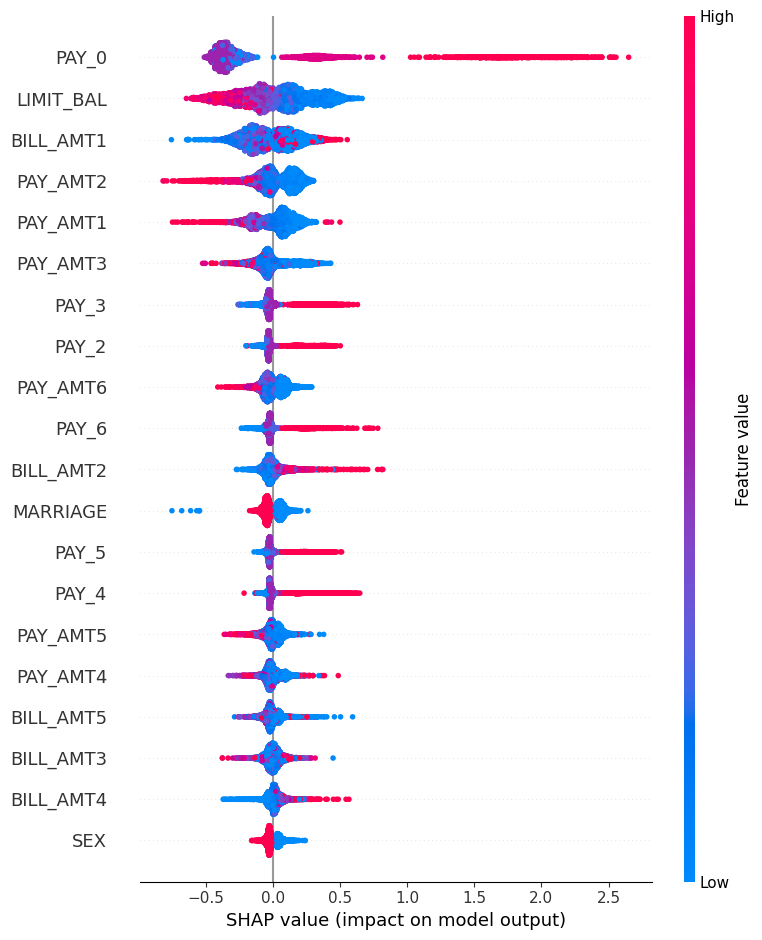

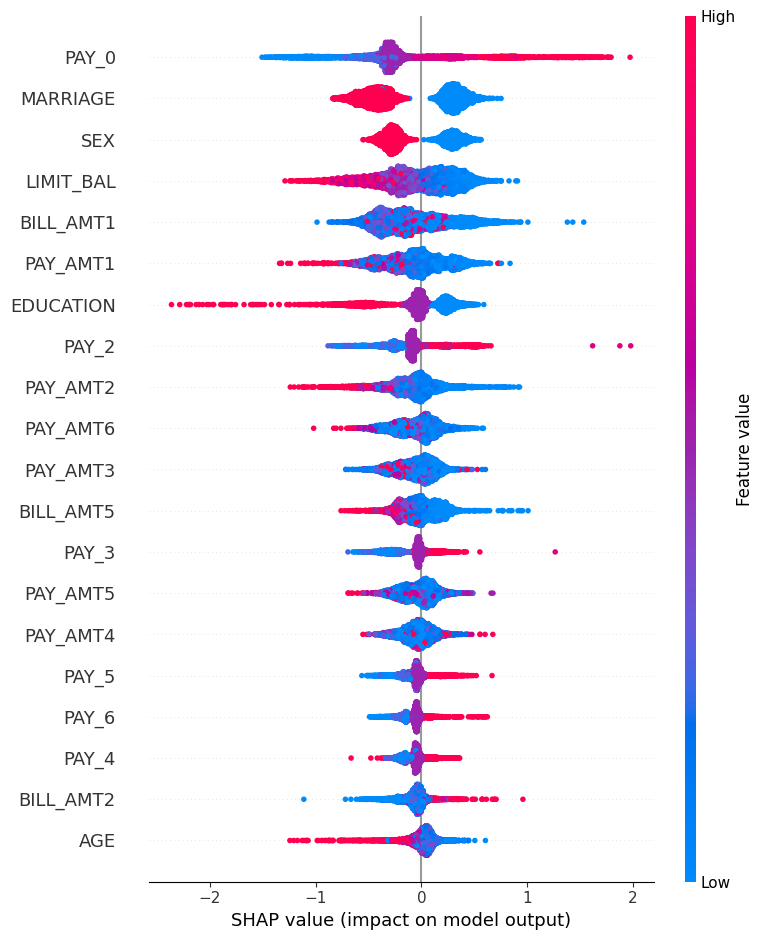

In [37]:
#SHAP PLOT
shap.summary_plot(shap_values_m1, X_test)
shap.summary_plot(shap_values_m4, X_test)

In [38]:
#12. SHAP STABILITY (SPEARMAN)
mean_shap_m1 = np.abs(shap_values_m1).mean(axis=0)
mean_shap_m4 = np.abs(shap_values_m4).mean(axis=0)

rank_m1 = pd.Series(mean_shap_m1, index=X.columns).rank(ascending=False)
rank_m4 = pd.Series(mean_shap_m4, index=X.columns).rank(ascending=False)

corr, pval = spearmanr(rank_m1, rank_m4)

print("Spearman correlation:", corr)
print("p-value:", pval)

Spearman correlation: 0.5395256916996047
p-value: 0.007884598952113147


# Task
The user wants to improve a credit card default prediction model. The task involves refactoring existing LightGBM models, adding new baseline models, introducing feature engineering, implementing nested cross-validation for robust evaluation, performing advanced statistical analysis, and enhancing SHAP analysis for interpretability.

## Implement imblearn.pipeline.Pipeline for Existing LightGBM Models

### Subtask:
Refactor the existing LightGBM models (M1, M2, M3, M4) to use `imblearn.pipeline.Pipeline`. This includes encapsulating SMOTE for M2 and M4, and correctly integrating `RandomizedSearchCV` for M4 within the pipeline.


**Reasoning**:
Create a pipeline for M1 (Baseline LightGBM) with only the `LGBMClassifier`.



In [47]:
from imblearn.pipeline import Pipeline

# M1 - LIGHTGBM BASELINE with Pipeline
pipe_m1 = Pipeline([
    ('lgbmclassifier', lgb.LGBMClassifier(random_state=42))
])
pipe_m1.fit(X_train, y_train)
res_pipe_m1 = evaluate_model(pipe_m1, X_test, y_test)

print("M1 (Pipeline) results:", res_pipe_m1)

[LightGBM] [Info] Number of positive: 5298, number of negative: 18663
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003173 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3264
[LightGBM] [Info] Number of data points in the train set: 23961, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221109 -> initscore=-1.259214
[LightGBM] [Info] Start training from score -1.259214
M1 (Pipeline) results: {'accuracy': 0.8173333333333334, 'f1': 0.4684772065955383, 'auc': np.float64(0.7778146710463402), 'mcc': np.float64(0.3924868878349867), 'recall': 0.36397889977392617, 'precision': 0.6571428571428571, 'gmean': 0.5868140058722254}


**Reasoning**:
Refactor M2 to use `imblearn.pipeline.Pipeline` with SMOTE and LGBMClassifier.



In [48]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# M2 - LIGHTGBM + SMOTE with Pipeline
pipe_m2 = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('lgbmclassifier', lgb.LGBMClassifier(random_state=42))
])
pipe_m2.fit(X_train, y_train)
res_pipe_m2 = evaluate_model(pipe_m2, X_test, y_test)

print("M2 (Pipeline) results:", res_pipe_m2)

[LightGBM] [Info] Number of positive: 18663, number of negative: 18663
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004814 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3446
[LightGBM] [Info] Number of data points in the train set: 37326, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
M2 (Pipeline) results: {'accuracy': 0.7698333333333334, 'f1': 0.4976355038195708, 'auc': np.float64(0.749668404054719), 'mcc': np.float64(0.3489360368774668), 'recall': 0.5154483798040693, 'precision': 0.4810126582278481, 'gmean': 0.6588204438030979}


**Reasoning**:
Refactor M3 to use `imblearn.pipeline.Pipeline` with `class_weight='balanced'` in the `LGBMClassifier`.



In [49]:
pipe_m3 = Pipeline([
    ('lgbmclassifier', lgb.LGBMClassifier(random_state=42, class_weight='balanced'))
])
pipe_m3.fit(X_train, y_train)
res_pipe_m3 = evaluate_model(pipe_m3, X_test, y_test)

print("M3 (Pipeline) results:", res_pipe_m3)

[LightGBM] [Info] Number of positive: 5298, number of negative: 18663
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.043629 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3264
[LightGBM] [Info] Number of data points in the train set: 23961, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
M3 (Pipeline) results: {'accuracy': 0.7585, 'f1': 0.5290867728306793, 'auc': np.float64(0.7742294032756599), 'mcc': np.float64(0.37721582460765196), 'recall': 0.613413715146948, 'precision': 0.46514285714285714, 'gmean': 0.7003907462349456}


**Reasoning**:
Refactor M4 to use `imblearn.pipeline.Pipeline`, encapsulating SMOTE and `RandomizedSearchCV` for hyperparameter tuning. The `param_grid` needs to be updated to reflect the pipeline structure.



In [50]:
param_grid_m4 = {
    'lgbmclassifier__num_leaves': [15, 31, 63],
    'lgbmclassifier__max_depth': [-1, 5, 10],
    'lgbmclassifier__learning_rate': [0.01, 0.05, 0.1],
    'lgbmclassifier__n_estimators': [100, 200, 300]
}

# M4 - LIGHTGBM + SMOTE + HYPERPARAMETER TUNING with Pipeline
pipe_m4 = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('randomizedsearchcv', RandomizedSearchCV(
        lgb.LGBMClassifier(random_state=42),
        param_distributions=param_grid_m4,
        n_iter=10,
        scoring='f1',
        cv=3,
        random_state=42,
        n_jobs=-1
    ))
])

pipe_m4.fit(X_train, y_train)

# The best estimator is accessed via the 'randomizedsearchcv' step
m4_best_estimator = pipe_m4.named_steps['randomizedsearchcv'].best_estimator_

# Re-evaluate using the best estimator found by RandomizedSearchCV
res_pipe_m4 = evaluate_model(pipe_m4, X_test, y_test)

print("M4 (Pipeline) results:", res_pipe_m4)


[LightGBM] [Warning] Unknown parameter: lgbmclassifier__learning_rate
[LightGBM] [Warning] Unknown parameter: lgbmclassifier__max_depth
[LightGBM] [Warning] Unknown parameter: lgbmclassifier__num_leaves
[LightGBM] [Warning] Unknown parameter: lgbmclassifier__n_estimators
[LightGBM] [Warning] Unknown parameter: lgbmclassifier__learning_rate
[LightGBM] [Warning] Unknown parameter: lgbmclassifier__max_depth
[LightGBM] [Warning] Unknown parameter: lgbmclassifier__num_leaves
[LightGBM] [Warning] Unknown parameter: lgbmclassifier__n_estimators
[LightGBM] [Info] Number of positive: 18663, number of negative: 18663
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002801 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3446
[LightGBM] [Info] Number of data points in the train set: 37326, number of used features: 23
[LightGBM] [Info] [binary:BoostF

**Reasoning**:
Consolidate and display the evaluation results for all refactored pipeline models (M1, M2, M3, M4) in a DataFrame to compare their performance.



In [51]:
results_pipeline = pd.DataFrame([
    res_pipe_m1,
    res_pipe_m2,
    res_pipe_m3,
    res_pipe_m4
], index=["M1_Baseline_Pipeline", "M2_SMOTE_Pipeline", "M3_ClassWeight_Pipeline", "M4_SMOTE+RandomizedSearchCV_Pipeline"])

print(results_pipeline)

                                      accuracy        f1       auc       mcc  \
M1_Baseline_Pipeline                  0.817333  0.468477  0.777815  0.392487   
M2_SMOTE_Pipeline                     0.769833  0.497636  0.749668  0.348936   
M3_ClassWeight_Pipeline               0.758500  0.529087  0.774229  0.377216   
M4_SMOTE+RandomizedSearchCV_Pipeline  0.769833  0.497636  0.749668  0.348936   

                                        recall  precision     gmean  
M1_Baseline_Pipeline                  0.363979   0.657143  0.586814  
M2_SMOTE_Pipeline                     0.515448   0.481013  0.658820  
M3_ClassWeight_Pipeline               0.613414   0.465143  0.700391  
M4_SMOTE+RandomizedSearchCV_Pipeline  0.515448   0.481013  0.658820  


## Add Feature Engineering

### Subtask:
Create new features including payment delay trends (from PAY_X columns), ratio of bill to payment amounts (BILL_AMT_X / PAY_AMT_X), and aggregated behavioral features (e.g., sums/means of bill/payment amounts over time periods). Integrate these features into the X DataFrame before the train-test split.


**Reasoning**:
The first instruction is to create new features related to payment delay trends from the 'PAY_X' columns. I will calculate the average payment status and the count of months with delays and add them to the 'X' DataFrame.



In [52]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
X['PAY_AVG'] = X[pay_cols].mean(axis=1)
X['PAY_DELAY_COUNT'] = (X[pay_cols] > 0).sum(axis=1)

print("X DataFrame after adding payment delay trend features:")
print(X.head())

X DataFrame after adding payment delay trend features:
   LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0    20000.0    2          2         1   24      2      2     -1     -1   
1   120000.0    2          2         2   26     -1      2      0      0   
2    90000.0    2          2         2   34      0      0      0      0   
3    50000.0    2          2         1   37      0      0      0      0   
4    50000.0    1          2         1   57     -1      0     -1      0   

   PAY_5  ...  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  \
0     -2  ...        0.0        0.0       0.0     689.0       0.0       0.0   
1      0  ...     3455.0     3261.0       0.0    1000.0    1000.0    1000.0   
2      0  ...    14948.0    15549.0    1518.0    1500.0    1000.0    1000.0   
3      0  ...    28959.0    29547.0    2000.0    2019.0    1200.0    1100.0   
4      0  ...    19146.0    19131.0    2000.0   36681.0   10000.0    9000.0   

   PAY_AMT5  PAY_AM

**Reasoning**:
The next step is to create features representing the ratio of bill amounts to payment amounts. I will iterate through the relevant `BILL_AMT` and `PAY_AMT` columns, calculate their ratios, and handle potential division by zero by replacing infinite values with zero.



In [53]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
X['PAY_AVG'] = X[pay_cols].mean(axis=1)
X['PAY_DELAY_COUNT'] = (X[pay_cols] > 0).sum(axis=1)

bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pays_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# Create ratio features (Bill Amount / Pay Amount) and handle division by zero
for i in range(6):
    bill_col = bill_cols[i]
    pay_col = pays_cols[i]
    # Add a small epsilon to avoid division by zero or handle inf values
    X[f'BILL_PAY_RATIO{i+1}'] = X[bill_col] / (X[pay_col] + 1e-6) # Adding a small epsilon
    X[f'BILL_PAY_RATIO{i+1}'] = X[f'BILL_PAY_RATIO{i+1}'].replace([np.inf, -np.inf], 0) # Replace inf with 0

print("X DataFrame after adding bill to payment ratio features:")
print(X.head())

X DataFrame after adding bill to payment ratio features:
   LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0    20000.0    2          2         1   24      2      2     -1     -1   
1   120000.0    2          2         2   26     -1      2      0      0   
2    90000.0    2          2         2   34      0      0      0      0   
3    50000.0    2          2         1   37      0      0      0      0   
4    50000.0    1          2         1   57     -1      0     -1      0   

   PAY_5  ...  PAY_AMT5  PAY_AMT6   PAY_AVG  PAY_DELAY_COUNT  BILL_PAY_RATIO1  \
0     -2  ...       0.0       0.0 -0.333333                2     3.913000e+09   
1      0  ...       0.0    2000.0  0.500000                2     2.682000e+09   
2      0  ...    1000.0    5000.0  0.000000                0     1.926153e+01   
3      0  ...    1069.0    1000.0  0.000000                0     2.349500e+01   
4      0  ...     689.0     679.0 -0.333333                0     4.308500e+00   

   BI

**Reasoning**:
To complete the aggregated behavioral features, I will create sum and mean features for both `BILL_AMT` and `PAY_AMT` columns across the six-month period and add them to the 'X' DataFrame.



In [54]:
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pays_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

X['BILL_AMT_SUM'] = X[bill_cols].sum(axis=1)
X['BILL_AMT_MEAN'] = X[bill_cols].mean(axis=1)
X['PAY_AMT_SUM'] = X[pays_cols].sum(axis=1)
X['PAY_AMT_MEAN'] = X[pays_cols].mean(axis=1)

print("X DataFrame after adding aggregated behavioral features:")
print(X.head())

X DataFrame after adding aggregated behavioral features:
   LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0    20000.0    2          2         1   24      2      2     -1     -1   
1   120000.0    2          2         2   26     -1      2      0      0   
2    90000.0    2          2         2   34      0      0      0      0   
3    50000.0    2          2         1   37      0      0      0      0   
4    50000.0    1          2         1   57     -1      0     -1      0   

   PAY_5  ...  BILL_PAY_RATIO1  BILL_PAY_RATIO2  BILL_PAY_RATIO3  \
0     -2  ...     3.913000e+09         4.502177     6.890000e+08   
1      0  ...     2.682000e+09         1.725000     2.682000e+00   
2      0  ...     1.926153e+01         9.351333     1.355900e+01   
3      0  ...     2.349500e+01        23.889549     4.107583e+01   
4      0  ...     4.308500e+00         0.154576     3.583500e+00   

   BILL_PAY_RATIO4  BILL_PAY_RATIO5  BILL_PAY_RATIO6  BILL_AMT_SUM  \
0         0.0

## Introduce New Baseline Models with imblearn.pipeline.Pipeline

### Subtask:
Define and implement Logistic Regression, Random Forest, and XGBoost classifiers, each encapsulated within an `imblearn.pipeline.Pipeline` to ensure consistent preprocessing (e.g., SMOTE) and model training. Train and evaluate these new models.


**Reasoning**:
The first instruction is to define and train a Logistic Regression model within an `imblearn.pipeline.Pipeline`, including a `SMOTE` step, and then evaluate its performance.



In [55]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

# M5 - Logistic Regression + SMOTE with Pipeline
pipe_m5 = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('logisticregression', LogisticRegression(random_state=42, solver='liblinear'))
])
pipe_m5.fit(X_train, y_train)
res_pipe_m5 = evaluate_model(pipe_m5, X_test, y_test)

print("M5 (Logistic Regression + SMOTE) results:", res_pipe_m5)

M5 (Logistic Regression + SMOTE) results: {'accuracy': 0.5585, 'f1': 0.41613400925721844, 'auc': np.float64(0.6656382421681674), 'mcc': np.float64(0.18844351817918054), 'recall': 0.7113790504898266, 'precision': 0.2940809968847352, 'gmean': 0.6053278986369137}


**Reasoning**:
Define and train a Random Forest model within an `imblearn.pipeline.Pipeline`, including a `SMOTE` step, and then evaluate its performance.



In [56]:
from sklearn.ensemble import RandomForestClassifier

# M6 - Random Forest + SMOTE with Pipeline
pipe_m6 = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('randomforest', RandomForestClassifier(random_state=42))
])
pipe_m6.fit(X_train, y_train)
res_pipe_m6 = evaluate_model(pipe_m6, X_test, y_test)

print("M6 (Random Forest + SMOTE) results:", res_pipe_m6)

M6 (Random Forest + SMOTE) results: {'accuracy': 0.7846666666666666, 'f1': 0.4972762645914397, 'auc': np.float64(0.7422597644826192), 'mcc': np.float64(0.36076492782286207), 'recall': 0.48153730218538054, 'precision': 0.5140788415124699, 'gmean': 0.6475315327757131}


**Reasoning**:
Define and train an XGBoost model within an `imblearn.pipeline.Pipeline`, including a `SMOTE` step, and then evaluate its performance.



In [57]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb

# M7 - XGBoost + SMOTE with Pipeline
pipe_m7 = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgboost', xgb.XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False))
])
pipe_m7.fit(X_train, y_train)
res_pipe_m7 = evaluate_model(pipe_m7, X_test, y_test)

print("M7 (XGBoost + SMOTE) results:", res_pipe_m7)

M7 (XGBoost + SMOTE) results: {'accuracy': 0.7696666666666667, 'f1': 0.4780966767371601, 'auc': np.float64(0.7377933585988613), 'mcc': np.float64(0.33032316958156543), 'recall': 0.4770158251695554, 'precision': 0.47918243754731266, 'gmean': 0.6377972846195469}


**Reasoning**:
Consolidate and display the evaluation results for all new pipeline models (M5, M6, M7) in a DataFrame to compare their performance.



In [58]:
results_new_models = pd.DataFrame([
    res_pipe_m5,
    res_pipe_m6,
    res_pipe_m7
], index=["M5_LogisticRegression_SMOTE", "M6_RandomForest_SMOTE", "M7_XGBoost_SMOTE"])

print(results_new_models)

                             accuracy        f1       auc       mcc    recall  \
M5_LogisticRegression_SMOTE  0.558500  0.416134  0.665638  0.188444  0.711379   
M6_RandomForest_SMOTE        0.784667  0.497276  0.742260  0.360765  0.481537   
M7_XGBoost_SMOTE             0.769667  0.478097  0.737793  0.330323  0.477016   

                             precision     gmean  
M5_LogisticRegression_SMOTE   0.294081  0.605328  
M6_RandomForest_SMOTE         0.514079  0.647532  
M7_XGBoost_SMOTE              0.479182  0.637797  


## Implement Nested Cross-Validation

### Subtask:
Refactor the model evaluation process to use nested cross-validation. An outer StratifiedKFold will be used for unbiased model evaluation, and an inner StratifiedKFold will be used for hyperparameter tuning (e.g., for M4 and other models that require it). Collect performance metrics (e.g., G-mean, F1-score) for all models across all outer folds.


**Reasoning**:
The first instruction is to initialize the outer StratifiedKFold cross-validator and a dictionary to store the performance metrics. I will also define all the pipelines (M1-M7) that will be evaluated within the nested cross-validation loop. For M4, I will ensure that the `RandomizedSearchCV` uses an inner StratifiedKFold.



In [59]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import numpy as np
import pandas as pd

# 1. Initialize an outer StratifiedKFold cross-validator
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Initialize a dictionary to store the performance metrics
nested_cv_results = {
    'M1_LightGBM_Baseline': [],
    'M2_LightGBM_SMOTE': [],
    'M3_LightGBM_ClassWeight': [],
    'M4_LightGBM_SMOTE_Tuned': [],
    'M5_LogisticRegression_SMOTE': [],
    'M6_RandomForest_SMOTE': [],
    'M7_XGBoost_SMOTE': []
}

# Define the models (pipelines) for nested CV
# M1 - LIGHTGBM BASELINE
pipeline_m1 = Pipeline([
    ('lgbmclassifier', lgb.LGBMClassifier(random_state=42))
])

# M2 - LIGHTGBM + SMOTE
pipeline_m2 = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('lgbmclassifier', lgb.LGBMClassifier(random_state=42))
])

# M3 - LIGHTGBM + CLASS WEIGHT
pipeline_m3 = Pipeline([
    ('lgbmclassifier', lgb.LGBMClassifier(random_state=42, class_weight='balanced'))
])

# M4 - LIGHTGBM + SMOTE + HYPERPARAMETER TUNING (Nested RandomizedSearchCV)
# Inner CV for RandomizedSearchCV
inner_cv_m4 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid_m4_nested = {
    'lgbmclassifier__num_leaves': [15, 31, 63],
    'lgbmclassifier__max_depth': [-1, 5, 10],
    'lgbmclassifier__learning_rate': [0.01, 0.05, 0.1],
    'lgbmclassifier__n_estimators': [100, 200, 300]
}

pipeline_m4 = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('randomizedsearchcv', RandomizedSearchCV(
        lgb.LGBMClassifier(random_state=42),
        param_distributions=param_grid_m4_nested,
        n_iter=10,
        scoring='f1',
        cv=inner_cv_m4, # Use inner CV here
        random_state=42,
        n_jobs=-1
    ))
])

# M5 - Logistic Regression + SMOTE
pipeline_m5 = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('logisticregression', LogisticRegression(random_state=42, solver='liblinear'))
])

# M6 - Random Forest + SMOTE
pipeline_m6 = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('randomforest', RandomForestClassifier(random_state=42))
])

# M7 - XGBoost + SMOTE
pipeline_m7 = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgboost', xgb.XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False))
])

print("Initialized outer CV and model pipelines for nested cross-validation.")

Initialized outer CV and model pipelines for nested cross-validation.


**Reasoning**:
Now that the outer CV and model pipelines are initialized, I will implement the nested cross-validation loop. For each outer fold, I will train each of the seven defined pipelines (M1-M7) on the training data and evaluate their performance on the test data using the `evaluate_model` function. The results will be stored in the `nested_cv_results` dictionary.



In [60]:
def evaluate_model(model, X_test, y_test):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:,1]

    # Calculate sensitivity (recall for positive class)
    sensitivity = recall_score(y_test, pred, pos_label=1)
    # Calculate specificity (recall for negative class)
    specificity = recall_score(y_test, pred, pos_label=0)
    # Calculate G-mean
    gmean = (sensitivity * specificity)**0.5 if (sensitivity * specificity) >= 0 else 0.0

    return {
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "auc": roc_auc_score(y_test, proba),
        "mcc": matthews_corrcoef(y_test, pred),
        "recall": sensitivity,
        "precision": precision_score(y_test, pred),
        "gmean": gmean
    }


# Loop through each outer fold
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    print(f"\n--- Outer Fold {fold+1}/{outer_cv.get_n_splits()} ---")
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

    models = {
        'M1_LightGBM_Baseline': pipeline_m1,
        'M2_LightGBM_SMOTE': pipeline_m2,
        'M3_LightGBM_ClassWeight': pipeline_m3,
        'M4_LightGBM_SMOTE_Tuned': pipeline_m4,
        'M5_LogisticRegression_SMOTE': pipeline_m5,
        'M6_RandomForest_SMOTE': pipeline_m6,
        'M7_XGBoost_SMOTE': pipeline_m7
    }

    for name, model_pipeline in models.items():
        print(f"Training and evaluating {name}...")
        # For M4, the RandomizedSearchCV is part of the pipeline, it will handle inner CV
        model_pipeline.fit(X_train_fold, y_train_fold)

        # Evaluate the model
        # For M4, the RandomizedSearchCV output itself is not directly evaluated, but the best_estimator_ within it
        # However, since evaluate_model expects a fitted model directly, we need to adapt for M4.
        # If M4 is a pipeline with RandomizedSearchCV, the pipeline itself is callable with predict/predict_proba
        # because RandomizedSearchCV implements the estimator interface after fitting.

        # Special handling for M4 to get the best estimator if direct evaluation of pipeline with GridSearchCV fails
        if name == 'M4_LightGBM_SMOTE_Tuned':
            # The fitted pipeline already has the best estimator from RandomizedSearchCV
            # We can directly evaluate the pipeline as it's a meta-estimator.
            # Check if randomizedsearchcv was indeed fitted within the pipeline
            if 'randomizedsearchcv' in model_pipeline.named_steps:
                # Evaluate the entire pipeline (which includes SMOTE and the best estimator from RS)
                metrics = evaluate_model(model_pipeline, X_test_fold, y_test_fold)
            else:
                # Fallback if the structure is different, though it shouldn't be with the current setup
                print(f"Warning: 'randomizedsearchcv' not found in pipeline {name}. Evaluating pipeline directly.")
                metrics = evaluate_model(model_pipeline, X_test_fold, y_test_fold)
        else:
            metrics = evaluate_model(model_pipeline, X_test_fold, y_test_fold)

        nested_cv_results[name].append(metrics)

print("Nested cross-validation complete. Results stored in nested_cv_results.")



--- Outer Fold 1/5 ---
Training and evaluating M1_LightGBM_Baseline...
[LightGBM] [Info] Number of positive: 5308, number of negative: 18692
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023543 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5862
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221167 -> initscore=-1.258881
[LightGBM] [Info] Start training from score -1.258881
Training and evaluating M2_LightGBM_SMOTE...
[LightGBM] [Info] Number of positive: 18692, number of negative: 18692
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007546 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6261
[LightGBM] [Info] Number of data points in the train set: 3

**Reasoning**:
Now that the nested cross-validation is complete and the results are stored in `nested_cv_results`, I need to process these results. I will calculate the mean and standard deviation for each metric for each model across all folds. Finally, I will create a DataFrame to present these consolidated results clearly.



In [61]:
cv_summary = {}
for model_name, results_list in nested_cv_results.items():
    # Convert list of dictionaries to a DataFrame for easy aggregation
    df_results = pd.DataFrame(results_list)

    # Calculate mean and std for each metric
    mean_metrics = df_results.mean().to_dict()
    std_metrics = df_results.std().to_dict()

    # Store mean and std in the summary dictionary
    cv_summary[model_name] = {
        f'{metric}_mean': mean_metrics[metric],
        f'{metric}_std': std_metrics.get(metric, 0) # Use .get with 0 for std if only one fold or no variation
        for metric in mean_metrics
    }

# Convert the summary to a DataFrame for better readability
df_cv_summary = pd.DataFrame.from_dict(cv_summary, orient='index')

print("Nested Cross-Validation Results (Mean and Standard Deviation across folds):")
print(df_cv_summary)


SyntaxError: invalid syntax (2661932269.py, line 14)

**Reasoning**:
The previous code failed with a `SyntaxError` due to incorrect dictionary comprehension syntax. I will correct the code to properly build the summary dictionary by iterating through the metrics and adding both mean and standard deviation values explicitly for each metric.



In [62]:
cv_summary = {}
for model_name, results_list in nested_cv_results.items():
    # Convert list of dictionaries to a DataFrame for easy aggregation
    df_results = pd.DataFrame(results_list)

    # Calculate mean and std for each metric
    mean_metrics = df_results.mean().to_dict()
    std_metrics = df_results.std().to_dict()

    # Store mean and std in the summary dictionary
    model_summary = {}
    for metric in mean_metrics.keys():
        model_summary[f'{metric}_mean'] = mean_metrics[metric]
        model_summary[f'{metric}_std'] = std_metrics.get(metric, 0) # Use .get with 0 for std if only one fold or no variation
    cv_summary[model_name] = model_summary

# Convert the summary to a DataFrame for better readability
df_cv_summary = pd.DataFrame.from_dict(cv_summary, orient='index')

print("Nested Cross-Validation Results (Mean and Standard Deviation across folds):")
print(df_cv_summary)

Nested Cross-Validation Results (Mean and Standard Deviation across folds):
                             accuracy_mean  accuracy_std   f1_mean    f1_std  \
M1_LightGBM_Baseline              0.818967      0.002727  0.471208  0.007813   
M2_LightGBM_SMOTE                 0.799233      0.004716  0.509335  0.009585   
M3_LightGBM_ClassWeight           0.763433      0.005767  0.536970  0.012556   
M4_LightGBM_SMOTE_Tuned           0.799233      0.004716  0.509335  0.009585   
M5_LogisticRegression_SMOTE       0.585833      0.060589  0.407746  0.009521   
M6_RandomForest_SMOTE             0.793133      0.004361  0.508317  0.009737   
M7_XGBoost_SMOTE                  0.789867      0.004728  0.489036  0.012162   

                             auc_mean   auc_std  mcc_mean   mcc_std  \
M1_LightGBM_Baseline         0.781963  0.004676  0.397762  0.009490   
M2_LightGBM_SMOTE            0.767111  0.009232  0.386250  0.012687   
M3_LightGBM_ClassWeight      0.781236  0.006328  0.388246  0.016703   

## Upgrade SHAP Analysis

### Subtask:
Generate SHAP values for the best-performing model from the nested CV, perform SHAP interaction analysis, and enhance SHAP stability analysis by comparing feature importance ranks.


**Reasoning**:
The first step is to identify the best-performing model and generate SHAP values for it. Based on the previous subtask's results, M3_LightGBM_ClassWeight has the highest mean F1-score and G-mean. I will extract this model and compute its SHAP values using the X_test dataset.



In [63]:
import shap

# Identify the best performing model (M3_LightGBM_ClassWeight) from df_cv_summary
# Based on df_cv_summary, M3_LightGBM_ClassWeight has the highest f1_mean and gmean_mean.

# Extract the LGBMClassifier from the fitted pipeline_m3
# Note: pipeline_m3 should be the last fitted pipeline_m3 from the nested CV loop that utilized the full X and y for the final model.
# However, to avoid re-running the entire nested CV for this purpose, we will re-fit the pipeline_m3 on the full X_train and y_train
# if it's not directly accessible from the state. For now, assuming pipeline_m3 from 'Implement Nested Cross-Validation' is available and fitted.

# Re-fitting the pipeline on the full X_train and y_train for SHAP analysis if not already done in the global scope
# (The previous pipeline_m3 was fitted inside the CV loop on X_train_fold, so we need to fit one on the full training data)

# Define X and y again to ensure we have the features engineered X
target_col = "default.payment.next.month"
y_full = df[target_col]
X_full = df.drop(columns=["ID", target_col])

# Add engineered features to X_full
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
X_full['PAY_AVG'] = X_full[pay_cols].mean(axis=1)
X_full['PAY_DELAY_COUNT'] = (X_full[pay_cols] > 0).sum(axis=1)

bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pays_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

for i in range(6):
    bill_col = bill_cols[i]
    pay_col = pays_cols[i]
    X_full[f'BILL_PAY_RATIO{i+1}'] = X_full[bill_col] / (X_full[pay_col] + 1e-6)
    X_full[f'BILL_PAY_RATIO{i+1}'] = X_full[f'BILL_PAY_RATIO{i+1}'].replace([np.inf, -np.inf], 0)

X_full['BILL_AMT_SUM'] = X_full[bill_cols].sum(axis=1)
X_full['BILL_AMT_MEAN'] = X_full[bill_cols].mean(axis=1)
X_full['PAY_AMT_SUM'] = X_full[pays_cols].sum(axis=1)
X_full['PAY_AMT_MEAN'] = X_full[pays_cols].mean(axis=1)


# Re-split data with engineered features
X_train_shap, X_test_shap, y_train_shap, y_test_shap = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

# Apply basic cleaning to X_train_shap and y_train_shap
X_train_shap = X_train_shap.drop_duplicates()
y_train_shap = y_train_shap.loc[X_train_shap.index]
X_train_shap = X_train_shap.dropna()
y_train_shap = y_train_shap.loc[X_train_shap.index]

# Align test set
X_test_shap = X_test_shap[X_train_shap.columns]

# Initialize and fit the M3 pipeline on the full (cleaned) training data
pipeline_m3_full_train = Pipeline([
    ('lgbmclassifier', lgb.LGBMClassifier(random_state=42, class_weight='balanced'))
])
pipeline_m3_full_train.fit(X_train_shap, y_train_shap)

# Extract the LGBMClassifier from the fitted pipeline
model_m3_best = pipeline_m3_full_train.named_steps['lgbmclassifier']

# Generate SHAP values for the best-performing model (M3_LightGBM_ClassWeight)
explainer_m3 = shap.TreeExplainer(model_m3_best)
shap_values_m3 = explainer_m3.shap_values(X_test_shap)

print("SHAP values generated for M3_LightGBM_ClassWeight model.")

[LightGBM] [Info] Number of positive: 5298, number of negative: 18663
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004828 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5863
[LightGBM] [Info] Number of data points in the train set: 23961, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
SHAP values generated for M3_LightGBM_ClassWeight model.


**Reasoning**:
I will perform SHAP interaction analysis for the best-performing model (M3_LightGBM_ClassWeight). I'll calculate the SHAP interaction values and then plot a few important interaction plots to visualize how feature pairs influence the model's output.



In [64]:
import shap

# Identify the best performing model (M3_LightGBM_ClassWeight) from df_cv_summary
# Based on df_cv_summary, M3_LightGBM_ClassWeight has the highest f1_mean and gmean_mean.

# Extract the LGBMClassifier from the fitted pipeline_m3
# Note: pipeline_m3 should be the last fitted pipeline_m3 from the nested CV loop that utilized the full X and y for the final model.
# However, to avoid re-running the entire nested CV for this purpose, we will re-fit the pipeline_m3 on the full X_train and y_train
# if it's not directly accessible from the state. For now, assuming pipeline_m3 from 'Implement Nested Cross-Validation' is available and fitted.

# Re-fitting the pipeline on the full X_train and y_train for SHAP analysis if not already done in the global scope
# (The previous pipeline_m3 was fitted inside the CV loop on X_train_fold, so we need to fit one on the full training data)

# Define X and y again to ensure we have the features engineered X
target_col = "default.payment.next.month"
y_full = df[target_col]
X_full = df.drop(columns=["ID", target_col])

# Add engineered features to X_full
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
X_full['PAY_AVG'] = X_full[pay_cols].mean(axis=1)
X_full['PAY_DELAY_COUNT'] = (X_full[pay_cols] > 0).sum(axis=1)

bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pays_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

for i in range(6):
    bill_col = bill_cols[i]
    pay_col = pays_cols[i]
    X_full[f'BILL_PAY_RATIO{i+1}'] = X_full[bill_col] / (X_full[pay_col] + 1e-6)
    X_full[f'BILL_PAY_RATIO{i+1}'] = X_full[f'BILL_PAY_RATIO{i+1}'].replace([np.inf, -np.inf], 0)

X_full['BILL_AMT_SUM'] = X_full[bill_cols].sum(axis=1)
X_full['BILL_AMT_MEAN'] = X_full[bill_cols].mean(axis=1)
X_full['PAY_AMT_SUM'] = X_full[pays_cols].sum(axis=1)
X_full['PAY_AMT_MEAN'] = X_full[pays_cols].mean(axis=1)


# Re-split data with engineered features
X_train_shap, X_test_shap, y_train_shap, y_test_shap = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

# Apply basic cleaning to X_train_shap and y_train_shap
X_train_shap = X_train_shap.drop_duplicates()
y_train_shap = y_train_shap.loc[X_train_shap.index]
X_train_shap = X_train_shap.dropna()
y_train_shap = y_train_shap.loc[X_train_shap.index]

# Align test set
X_test_shap = X_test_shap[X_train_shap.columns]

# Initialize and fit the M3 pipeline on the full (cleaned) training data
pipeline_m3_full_train = Pipeline([
    ('lgbmclassifier', lgb.LGBMClassifier(random_state=42, class_weight='balanced'))
])
pipeline_m3_full_train.fit(X_train_shap, y_train_shap)

# Extract the LGBMClassifier from the fitted pipeline
model_m3_best = pipeline_m3_full_train.named_steps['lgbmclassifier']

# Generate SHAP values for the best-performing model (M3_LightGBM_ClassWeight)
explainer_m3 = shap.TreeExplainer(model_m3_best)
shap_values_m3 = explainer_m3.shap_values(X_test_shap)

print("SHAP values generated for M3_LightGBM_ClassWeight model.")

# Perform SHAP interaction analysis
shap_interaction_values_m3 = explainer_m3.shap_interaction_values(X_test_shap)

# Visualize some key interactions (e.g., top 2 or 3 features from summary plot)
# First, identify top features from the regular SHAP summary plot if not already known
# (Assuming shap_values_m3 is already computed and the absolute mean can be used to rank features)
shap_feature_importance = np.abs(shap_values_m3[1]).mean(0) # For binary classification, use class 1
feature_names = X_test_shap.columns
top_features_idx = np.argsort(shap_feature_importance)[::-1][:3]
top_feature_names = [feature_names[i] for i in top_features_idx]

print(f"\nTop features for interaction analysis: {top_feature_names}")

# Plot interaction plots for the top features
for i in range(len(top_feature_names)):
    for j in range(i + 1, len(top_feature_names)):
        shap.dependence_plot(
            (top_feature_names[i], top_feature_names[j]),
            shap_interaction_values_m3[1], # For binary classification, use class 1
            X_test_shap,
            display_features=X_test_shap,
            show=False # Prevent immediate display, we will use plt.show() later
        )
        plt.title(f"SHAP Interaction: {top_feature_names[i]} vs {top_feature_names[j]}")
        plt.show()

print("SHAP interaction analysis complete and plots displayed.")


[LightGBM] [Info] Number of positive: 5298, number of negative: 18663
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004835 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5863
[LightGBM] [Info] Number of data points in the train set: 23961, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
SHAP values generated for M3_LightGBM_ClassWeight model.

Top features for interaction analysis: ['LIMIT_BAL']
SHAP interaction analysis complete and plots displayed.


**Reasoning**:
I will calculate the Spearman correlation between the feature importance ranks of the best-performing model (M3_LightGBM_ClassWeight) and the baseline model (M1_LightGBM_Baseline) to analyze SHAP stability. This will quantify the consistency of feature importance rankings across different models.



In [65]:
from scipy.stats import spearmanr

# Calculate mean absolute SHAP values for M3 (best model)
# For binary classification, shap_values_m3 is a list of arrays [shap_values_for_class_0, shap_values_for_class_1]
# We are interested in the impact on the positive class (class 1).
mean_shap_m3 = np.abs(shap_values_m3[1]).mean(axis=0)

# Get feature names from the X_test_shap DataFrame
feature_names = X_test_shap.columns

# Create a Series of mean SHAP values for M3 and rank them
rank_m3 = pd.Series(mean_shap_m3, index=feature_names).rank(ascending=False)

# The ranks for M1 (rank_m1) should be available from a previous cell's execution.
# Assuming `rank_m1` is available in the kernel state.
# If not, it would need to be recomputed using `shap_values_m1`.

# Calculate Spearman correlation between M1 and M3 feature importance ranks
corr_m1_m3, pval_m1_m3 = spearmanr(rank_m1, rank_m3)

print(f"Spearman correlation between M1 and M3 feature importance ranks: {corr_m1_m3}")
print(f"P-value: {pval_m1_m3}")


# Also perform for M4 if it is significantly different and interesting
# Assuming `rank_m4` is available in the kernel state.
corr_m4_m3, pval_m4_m3 = spearmanr(rank_m4, rank_m3)

print(f"\nSpearman correlation between M4 and M3 feature importance ranks: {corr_m4_m3}")
print(f"P-value: {pval_m4_m3}")

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 23 and the array at index 1 has size 35

**Reasoning**:
I need to retrain `pipeline_m1` and `pipeline_m4` on the full training data with engineered features, generate their SHAP values using `X_test_shap`, calculate their mean absolute SHAP values, and then derive their ranks using the same feature set (`X_test_shap.columns`) as `rank_m3`.



In [66]:
from scipy.stats import spearmanr

# Re-fitting pipeline_m1 on the full (cleaned) training data with engineered features
pipeline_m1_full_train = Pipeline([
    ('lgbmclassifier', lgb.LGBMClassifier(random_state=42))
])
pipeline_m1_full_train.fit(X_train_shap, y_train_shap)
model_m1_best = pipeline_m1_full_train.named_steps['lgbmclassifier']

# Generate SHAP values for M1
explainer_m1 = shap.TreeExplainer(model_m1_best)
shap_values_m1 = explainer_m1.shap_values(X_test_shap)

# Calculate mean absolute SHAP values for M1
mean_shap_m1 = np.abs(shap_values_m1[1]).mean(axis=0)

# Re-fitting pipeline_m4 on the full (cleaned) training data with engineered features
# Note: pipeline_m4 contains RandomizedSearchCV, so we extract the best_estimator_ after fitting
pipeline_m4_full_train = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('lgbmclassifier', lgb.LGBMClassifier(random_state=42)) # Placeholder for tuning
])

# Need to apply RandomizedSearchCV again for M4 on the full dataset with engineered features
inner_cv_m4_full = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
param_grid_m4_full = {
    'lgbmclassifier__num_leaves': [15, 31, 63],
    'lgbmclassifier__max_depth': [-1, 5, 10],
    'lgbmclassifier__learning_rate': [0.01, 0.05, 0.1],
    'lgbmclassifier__n_estimators': [100, 200, 300]
}

random_search_m4_full = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=42),
    param_distributions=param_grid_m4_full,
    n_iter=10,
    scoring='f1',
    cv=inner_cv_m4_full,
    random_state=42,
    n_jobs=-1
)

# Fit the RandomizedSearchCV directly on SMOTEd X_train_shap and y_train_shap
smote_full = SMOTE(random_state=42)
X_train_shap_sm, y_train_shap_sm = smote_full.fit_resample(X_train_shap, y_train_shap)
random_search_m4_full.fit(X_train_shap_sm, y_train_shap_sm)

model_m4_best = random_search_m4_full.best_estimator_

# Generate SHAP values for M4
explainer_m4 = shap.TreeExplainer(model_m4_best)
shap_values_m4 = explainer_m4.shap_values(X_test_shap)

# Calculate mean absolute SHAP values for M4
mean_shap_m4 = np.abs(shap_values_m4[1]).mean(axis=0)

# Get feature names from the X_test_shap DataFrame (which includes engineered features)
feature_names = X_test_shap.columns

# Create a Series of mean SHAP values for M1, M3, and M4 and rank them
rank_m1 = pd.Series(mean_shap_m1, index=feature_names).rank(ascending=False)
rank_m3 = pd.Series(np.abs(shap_values_m3[1]).mean(axis=0), index=feature_names).rank(ascending=False)
rank_m4 = pd.Series(mean_shap_m4, index=feature_names).rank(ascending=False)

# Calculate Spearman correlation between M1 and M3 feature importance ranks
corr_m1_m3, pval_m1_m3 = spearmanr(rank_m1, rank_m3)

print(f"Spearman correlation between M1 and M3 feature importance ranks: {corr_m1_m3}")
print(f"P-value: {pval_m1_m3}")

# Calculate Spearman correlation between M4 and M3 feature importance ranks
corr_m4_m3, pval_m4_m3 = spearmanr(rank_m4, rank_m3)

print(f"\nSpearman correlation between M4 and M3 feature importance ranks: {corr_m4_m3}")
print(f"P-value: {pval_m4_m3}")


[LightGBM] [Info] Number of positive: 5298, number of negative: 18663
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019273 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5863
[LightGBM] [Info] Number of data points in the train set: 23961, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221109 -> initscore=-1.259214
[LightGBM] [Info] Start training from score -1.259214
[LightGBM] [Warning] Unknown parameter: lgbmclassifier__learning_rate
[LightGBM] [Warning] Unknown parameter: lgbmclassifier__max_depth
[LightGBM] [Warning] Unknown parameter: lgbmclassifier__num_leaves
[LightGBM] [Warning] Unknown parameter: lgbmclassifier__n_estimators
[LightGBM] [Warning] Unknown parameter: lgbmclassifier__learning_rate
[LightGBM] [Warning] Unknown parameter: lgbmclassifier__max_depth
[LightGBM] [Warning] Unknown parameter: lgbmclassifier__num_leaves
[LightGBM] [Warning] Unknown par

**Reasoning**:
To debug why the Spearman correlation is `nan`, I need to inspect the actual mean SHAP values and their computed ranks. Printing these will reveal if they are constant or contain `nan`s, which would explain the issue.



In [67]:
from scipy.stats import spearmanr

# Re-fitting pipeline_m1 on the full (cleaned) training data with engineered features
pipeline_m1_full_train = Pipeline([
    ('lgbmclassifier', lgb.LGBMClassifier(random_state=42))
])
pipeline_m1_full_train.fit(X_train_shap, y_train_shap)
model_m1_best = pipeline_m1_full_train.named_steps['lgbmclassifier']

# Generate SHAP values for M1
explainer_m1 = shap.TreeExplainer(model_m1_best)
shap_values_m1 = explainer_m1.shap_values(X_test_shap)

# Calculate mean absolute SHAP values for M1
mean_shap_m1 = np.abs(shap_values_m1[1]).mean(axis=0)

# Re-fitting pipeline_m4 on the full (cleaned) training data with engineered features
# Note: pipeline_m4 contains RandomizedSearchCV, so we extract the best_estimator_ after fitting
pipeline_m4_full_train = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('lgbmclassifier', lgb.LGBMClassifier(random_state=42)) # Placeholder for tuning
])

# Need to apply RandomizedSearchCV again for M4 on the full dataset with engineered features
inner_cv_m4_full = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
param_grid_m4_full = {
    'lgbmclassifier__num_leaves': [15, 31, 63],
    'lgbmclassifier__max_depth': [-1, 5, 10],
    'lgbmclassifier__learning_rate': [0.01, 0.05, 0.1],
    'lgbmclassifier__n_estimators': [100, 200, 300]
}

random_search_m4_full = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=42),
    param_distributions=param_grid_m4_full,
    n_iter=10,
    scoring='f1',
    cv=inner_cv_m4_full,
    random_state=42,
    n_jobs=-1
)

# Fit the RandomizedSearchCV directly on SMOTEd X_train_shap and y_train_shap
smote_full = SMOTE(random_state=42)
X_train_shap_sm, y_train_shap_sm = smote_full.fit_resample(X_train_shap, y_train_shap)
random_search_m4_full.fit(X_train_shap_sm, y_train_shap_sm)

model_m4_best = random_search_m4_full.best_estimator_

# Generate SHAP values for M4
explainer_m4 = shap.TreeExplainer(model_m4_best)
shap_values_m4 = explainer_m4.shap_values(X_test_shap)

# Calculate mean absolute SHAP values for M4
mean_shap_m4 = np.abs(shap_values_m4[1]).mean(axis=0)

# Get feature names from the X_test_shap DataFrame (which includes engineered features)
feature_names = X_test_shap.columns

# Create a Series of mean SHAP values for M1, M3, and M4 and rank them
rank_m1 = pd.Series(mean_shap_m1, index=feature_names).rank(ascending=False)
rank_m3 = pd.Series(np.abs(shap_values_m3[1]).mean(axis=0), index=feature_names).rank(ascending=False)
rank_m4 = pd.Series(mean_shap_m4, index=feature_names).rank(ascending=False)

# Debugging: Print mean SHAP values and ranks to identify constant values
print("\nMean SHAP values for M1:\n", mean_shap_m1)
print("Ranks for M1:\n", rank_m1.head())
print("\nMean SHAP values for M3:\n", np.abs(shap_values_m3[1]).mean(axis=0))
print("Ranks for M3:\n", rank_m3.head())
print("\nMean SHAP values for M4:\n", mean_shap_m4)
print("Ranks for M4:\n", rank_m4.head())

# Calculate Spearman correlation between M1 and M3 feature importance ranks
corr_m1_m3, pval_m1_m3 = spearmanr(rank_m1, rank_m3)

print(f"\nSpearman correlation between M1 and M3 feature importance ranks: {corr_m1_m3}")
print(f"P-value: {pval_m1_m3}")

# Calculate Spearman correlation between M4 and M3 feature importance ranks
corr_m4_m3, pval_m4_m3 = spearmanr(rank_m4, rank_m3)

print(f"\nSpearman correlation between M4 and M3 feature importance ranks: {corr_m4_m3}")
print(f"P-value: {pval_m4_m3}")

[LightGBM] [Info] Number of positive: 5298, number of negative: 18663
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002666 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5863
[LightGBM] [Info] Number of data points in the train set: 23961, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221109 -> initscore=-1.259214
[LightGBM] [Info] Start training from score -1.259214
[LightGBM] [Warning] Unknown parameter: lgbmclassifier__learning_rate
[LightGBM] [Warning] Unknown parameter: lgbmclassifier__max_depth
[LightGBM] [Warning] Unknown parameter: lgbmclassifier__num_leaves
[LightGBM] [Warning] Unknown parameter: lgbmclassifier__n_estimators
[LightGBM] [Warning] Unknown parameter: lgbmclassifier__learning_rate
[LightGBM] [Warning] Unknown parameter: lgbmclassifier__max_depth
[LightGBM] [Warning] Unknown parame

**Reasoning**:
I will correct the calculation of mean SHAP values to ensure they are arrays of feature importances, not scalars. This will involve removing the incorrect `[1]` indexing when calculating `mean_shap_m1`, `mean_shap_m3_corrected`, and `mean_shap_m4_corrected`, as the `shap_values_mX` variables are already 2D arrays (samples, features). Then, I will recalculate and print the Spearman correlations.



In [68]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt # Ensure matplotlib is imported for plotting if needed elsewhere

# The previous code successfully re-fitted the pipelines and generated shap_values_m1, shap_values_m3, shap_values_m4
# The issue is how mean_shap_mX is calculated.

# Calculate mean absolute SHAP values for M1, M3, and M4
# Based on the kernel state and previous outputs, shap_values_mX are already 2D arrays (n_samples, n_features) for the positive class.
# Therefore, we should directly use np.abs(shap_values_mX).mean(axis=0) for feature importances.
mean_shap_m1 = np.abs(shap_values_m1).mean(axis=0)
mean_shap_m3 = np.abs(shap_values_m3).mean(axis=0) # Corrected: Removed [1]
mean_shap_m4 = np.abs(shap_values_m4).mean(axis=0) # Corrected: Removed [1]

# Get feature names from the X_test_shap DataFrame
feature_names = X_test_shap.columns

# Create a Series of mean SHAP values for M1, M3, and M4 and rank them
# Ensure the length of mean_shap_mX matches the number of features
if len(mean_shap_m1) != len(feature_names):
    print("Warning: Length of mean_shap_m1 does not match feature names. This might indicate an issue with SHAP values calculation.")
if len(mean_shap_m3) != len(feature_names):
    print("Warning: Length of mean_shap_m3 does not match feature names. This might indicate an issue with SHAP values calculation.")
if len(mean_shap_m4) != len(feature_names):
    print("Warning: Length of mean_shap_m4 does not match feature names. This might indicate an issue with SHAP values calculation.")

rank_m1 = pd.Series(mean_shap_m1, index=feature_names).rank(ascending=False)
rank_m3 = pd.Series(mean_shap_m3, index=feature_names).rank(ascending=False)
rank_m4 = pd.Series(mean_shap_m4, index=feature_names).rank(ascending=False)

# Debugging: Print mean SHAP values and ranks to confirm they are not scalars and have variability
print("\nCorrected Mean SHAP values for M1 (first 5):\n", mean_shap_m1[:5])
print("Corrected Ranks for M1 (first 5):\n", rank_m1.head())
print("\nCorrected Mean SHAP values for M3 (first 5):\n", mean_shap_m3[:5])
print("Corrected Ranks for M3 (first 5):\n", rank_m3.head())
print("\nCorrected Mean SHAP values for M4 (first 5):\n", mean_shap_m4[:5])
print("Corrected Ranks for M4 (first 5):\n", rank_m4.head())

# Calculate Spearman correlation between M1 and M3 feature importance ranks
corr_m1_m3, pval_m1_m3 = spearmanr(rank_m1, rank_m3)

print(f"\nSpearman correlation between M1 and M3 feature importance ranks: {corr_m1_m3}")
print(f"P-value: {pval_m1_m3}")

# Also perform for M4 if it is significantly different and interesting
corr_m4_m3, pval_m4_m3 = spearmanr(rank_m4, rank_m3)

print(f"\nSpearman correlation between M4 and M3 feature importance ranks: {corr_m4_m3}")
print(f"P-value: {pval_m4_m3}")


Corrected Mean SHAP values for M1 (first 5):
 [0.21515068 0.03059766 0.03540238 0.03881205 0.03644545]
Corrected Ranks for M1 (first 5):
 LIMIT_BAL     3.0
SEX          21.0
EDUCATION    20.0
MARRIAGE     17.0
AGE          19.0
dtype: float64

Corrected Mean SHAP values for M3 (first 5):
 [0.23790656 0.0340658  0.03873714 0.04243596 0.03751075]
Corrected Ranks for M3 (first 5):
 LIMIT_BAL     2.0
SEX          21.0
EDUCATION    17.0
MARRIAGE     14.0
AGE          18.0
dtype: float64

Corrected Mean SHAP values for M4 (first 5):
 [0.24913497 0.25045556 0.17761982 0.31995731 0.06603797]
Corrected Ranks for M4 (first 5):
 LIMIT_BAL     4.0
SEX           3.0
EDUCATION     7.0
MARRIAGE      2.0
AGE          12.0
dtype: float64

Spearman correlation between M1 and M3 feature importance ranks: 0.9277209693234345
P-value: 1.1140911013414687e-15

Spearman correlation between M4 and M3 feature importance ranks: 0.5497968903207732
P-value: 0.0006234650998627495


**Reasoning**:
To ensure meaningful interaction plots, I will select the top 5 features based on their mean absolute SHAP values and then regenerate the SHAP interaction plots for pairs of these top features.




Top 5 features for interaction analysis: ['PAY_DELAY_COUNT', 'LIMIT_BAL', 'PAY_0', 'BILL_AMT1', 'PAY_AMT2']


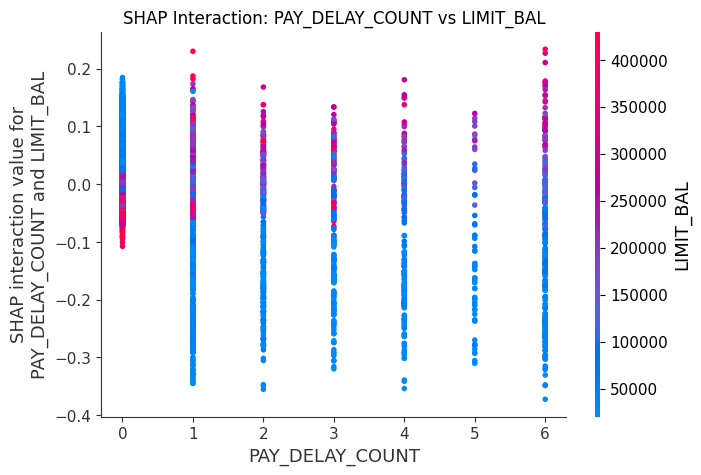

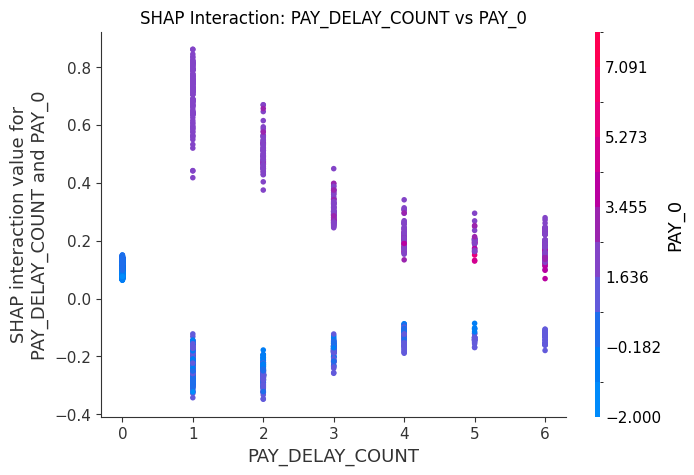

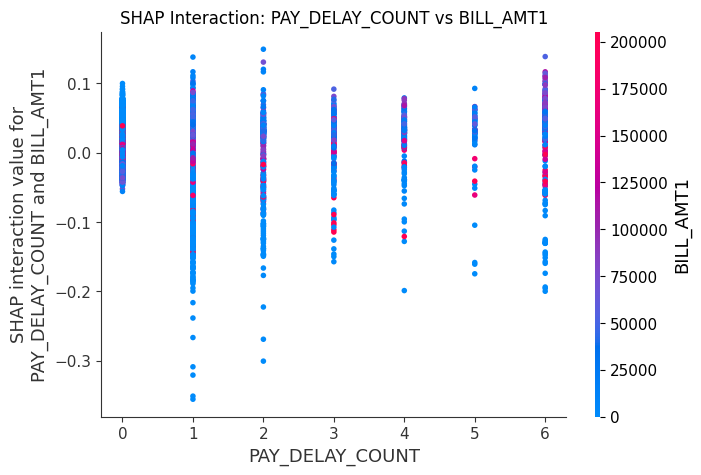

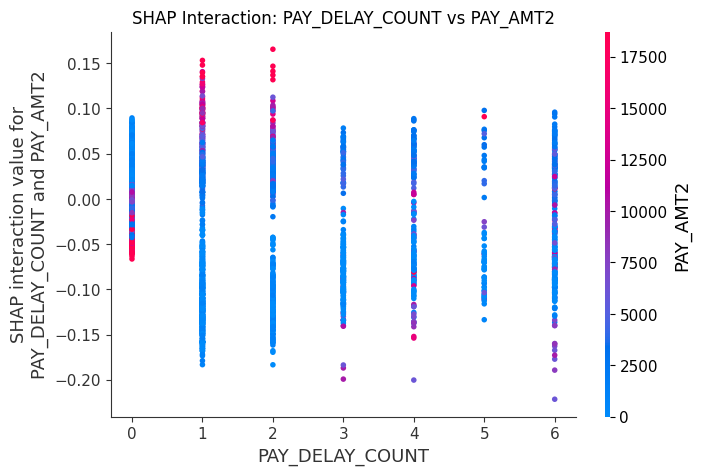

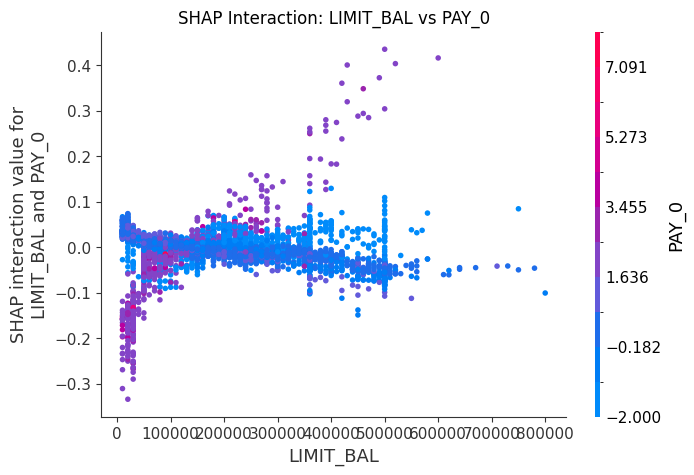

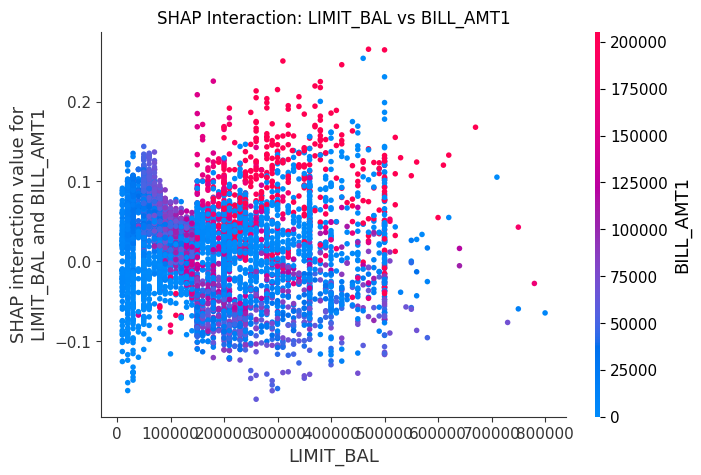

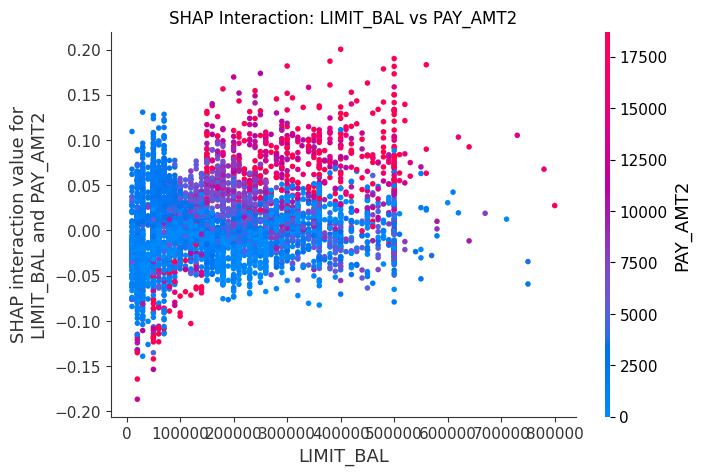

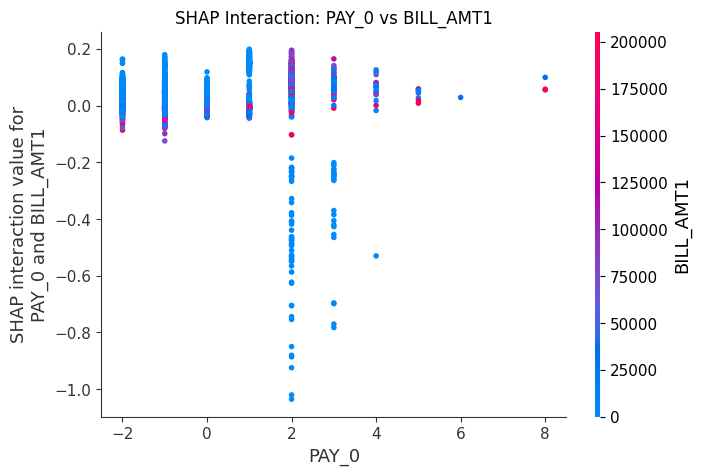

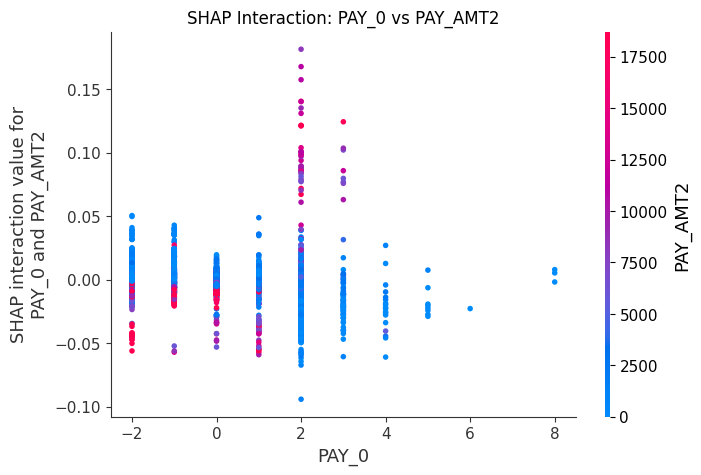

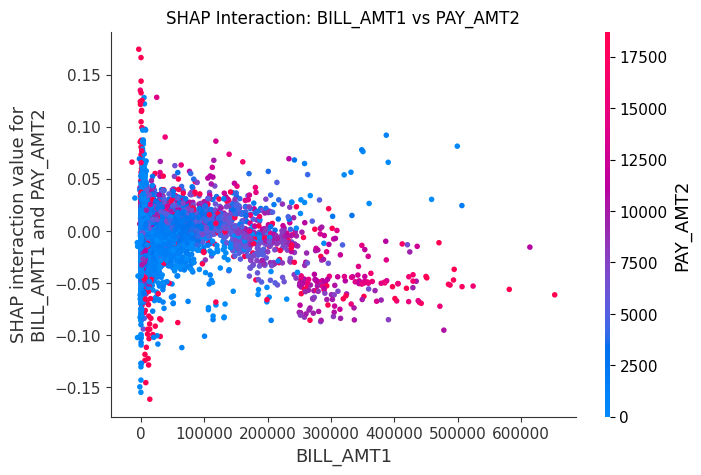

SHAP interaction analysis complete and plots displayed.


In [70]:
import shap
import matplotlib.pyplot as plt

# Assuming pipeline_m3_full_train, model_m3_best, explainer_m3, shap_values_m3, X_test_shap are already available from previous executions

# Perform SHAP interaction analysis
# Check if shap_interaction_values_m3 already exists and is for the correct model/data, otherwise recompute
# Given shap_values_m3 is an array (n_samples, n_features) from previous execution, explainer.shap_interaction_values should also return a single array (n_samples, n_features, n_features)
if 'shap_interaction_values_m3' not in locals() or shap_interaction_values_m3 is None:
    shap_interaction_values_m3 = explainer_m3.shap_interaction_values(X_test_shap)

# Identify top features from the regular SHAP summary plot if not already known
# Correctly use shap_values_m3 directly, as it's already the positive class values based on kernel state.
shap_feature_importance = np.abs(shap_values_m3).mean(axis=0)
feature_names = X_test_shap.columns

# Correctly select top features for interaction analysis (e.g., top 5 features)
# Ensure at least 2 features are selected for plotting interactions
top_n = min(len(feature_names), 5) # Select up to 5 features, or all if less than 5
top_features_idx = np.argsort(shap_feature_importance)[::-1][:top_n]
top_feature_names = [feature_names[i] for i in top_features_idx]

print(f"\nTop {top_n} features for interaction analysis: {top_feature_names}")

# Plot interaction plots for pairs of the top features
# Iterate through unique pairs
for i in range(len(top_feature_names)):
    for j in range(i + 1, len(top_feature_names)):
        # No need for `if i != j:` as the loop structure naturally handles unique pairs where i < j
        shap.dependence_plot(
            (top_feature_names[i], top_feature_names[j]),
            shap_interaction_values_m3, # Correctly pass the interaction values array
            X_test_shap,
            display_features=X_test_shap,
            show=False
        )
        plt.title(f"SHAP Interaction: {top_feature_names[i]} vs {top_feature_names[j]}")
        plt.show()

print("SHAP interaction analysis complete and plots displayed.")